<a href="https://colab.research.google.com/github/KrasnovaOV/A-B-test/blob/main/%D0%9F%D0%97_%D1%84%D0%BE%D1%80%D0%BC%D1%83%D0%BB%D0%B8%D1%80%D1%83%D0%B5%D0%BC_%D0%BE%D1%86%D0%B5%D0%BD%D0%B8%D0%B2%D0%B0%D0%B5%D0%BC_%D0%BF%D1%80%D0%B8%D0%BE%D1%80%D0%B8%D1%82%D0%B8%D0%B7%D0%B8%D1%80%D1%83%D0%B5%D0%BC_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7%D1%8B%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Задание
Вопросы по заданию
Мы предлагаем вам 2 уровня выполнения заданий в течение курса. Выберите подходящий для вас:

Работайте в Excel, если хотите научиться проводить A/B тестирование с использованием данного инструмента.
Выполняйте домашнее задание в Python, если вы уже успешно справляетесь с Excel и хотите прокачать навыки работы с другим инструментом.
Важно помнить, что все домашние задания выполняются с использованием данных тестового датасета. Перед вами датасет по сессиям пользователей мобильного приложения Gett. Загрузите файл с данными и шаблон для выполнения домашнего задания.

Поля:
· User_id — id пользователя.
· Hour — час старта сессии.
· App_opened — приложение открыто.
· Price_seen — пользователь ввёл данные маршрута и показана цена.
· Order_made — пользователь кликнул по кнопке заказа.
· Surge — в этот период был включен surge (надбавка к стоимости поездки в период повышенного спроса).
· Ride_completed — поездка успешно завершена.
· User_cancelled — пользователь отменил поездку.
· Age — возраст пользователя.
· City_center_order — заказ был сделан из центра города.
· Distance — дистанция в км.
· Rfm — rfm-сегмент пользователя.

Ваша цель:
· проанализировать данные;
· сформулировать гипотезы для проверки и определить их качество;
· приоритизировать гипотезы.

Инструкция к выполнению задания
Сделайте копию шаблона для домашнего задания и работайте в ней.

Составьте минимум 5 SMART-гипотез на основе проведенного анализа. Не ограничивайте себя, дайте волю фантазии. Не критикуйте себя на этом этапе. Зафиксируйте результат в первом столбце таблицы из шаблона.
Далее в столбце «Источник» укажите, с опорой на какие данные вы сформулировали эту гипотезу.
Оцените гипотезы в столбце «Оценка» с точки зрения их привлекательности от 1 до 10. Когда выставляете оценки, учитывайте:
– насколько сильно гипотеза может повлиять на ключевые метрики;
– насколько гипотеза подтверждается данными или предыдущими исследованиями;
– сколько ресурсов (время, деньги, усилия разработчиков) потребуется для проверки гипотезы.
Далее подробно опишите, почему вы оценили гипотезы именно так в соответствующем столбце.
В конце просмотрите гипотезы еще раз и укажите, какие из них не стоит проверять. Объясните, почему.
6.* Если готовы углубиться в тему, выполните бонусное задание. Приоритизируйте оставшиеся гипотезы c помощью фреймворка ICE. При расчёте каждой составляющей ICE опирайтесь на собственные представления о стоимости поездок, работ разработчиков и т. д. На этом этапе главное — понять, как работает приоритизация.

### 1. Пропуски в данных (по ключевым колонкам) ###
app_opened               0
price_seen               0
order_made               0
ride_completed           0
user_cancelled           0
surge                    0
city_center_order        0
distance             10069
age                      0
rfm                      0
dtype: int64

### 2. Воронка конверсии (в абсолютных числах) ###
{'App_opened': np.int64(101500), 'Price_seen': np.int64(91431), 'Order_made': np.int64(74236), 'Ride_completed': np.int64(62967)}

### 3. Воронка конверсии (в процентах) ###
App -> Price: 90.08%
Price -> Order: 81.19%
Order -> Complete: 84.82%


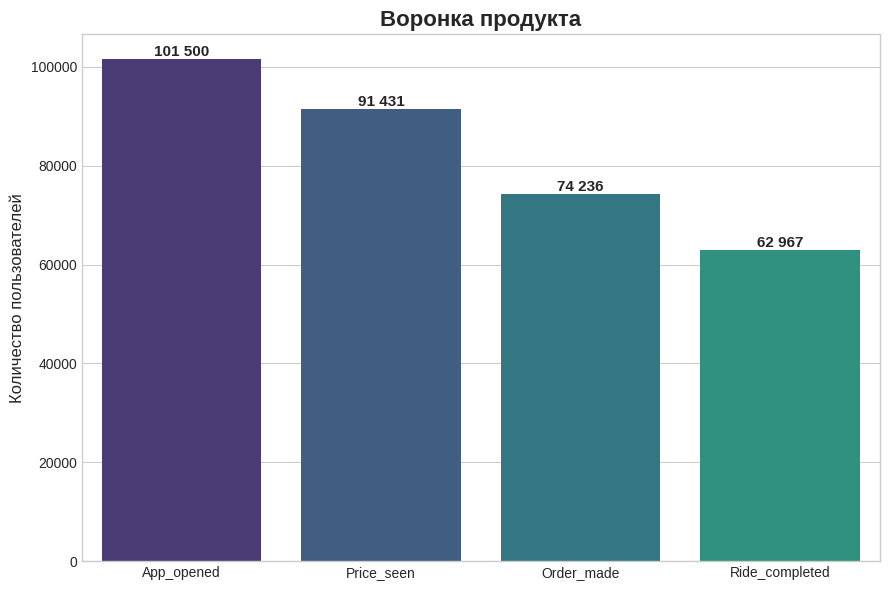


### 4. Процент отмен (общий и при Surge) ###
Общий процент отмен: 11.10%
surge
True    11.102463
Name: user_cancelled, dtype: float64

### 5. Конверсия в заказ: Центр vs Не центр ###
city_center_order
False    68.418631
True     76.675571
Name: order_made, dtype: float64

### 6. Распределение RFM сегментов ###
rfm
low       50436
high      47267
medium     3797
Name: count, dtype: int64

### 7. Конверсия в заказ по возрастным группам ###
age_bin
<18      74.341984
18-25    73.361219
26-35    72.772660
36-45    73.390850
46-60    70.300628
60+      23.841060
Name: order_made, dtype: float64

### 8. Сформулированные SMART-гипотезы ###
   №                                           Гипотеза  Оценка
0  1  Если показывать прозрачную причину Surge (напр...       8
1  2  Пользователи сегмента RFM "low" (50 436 чел.),...       9
2  3  Если для пользователей 60+ лет (конверсия в за...       7
3  4  Перенос кнопки "Заказать" на 200px выше (выше ...       6
4  5  Если добавить кнопку "Заказать э

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков для читаемости
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# --- 1. Загрузка и автоматическая очистка названий колонок ---
try:
    df = pd.read_excel('new_dataframe.xlsx')
except FileNotFoundError:
    print("Файл 'new_dataframe.xlsx' не найден. Загрузите его в корень среды Colab через вкладку 'Файлы' (слева).")
    df = None
except Exception as e:
    print(f"Ошибка при чтении файла: {e}")
    df = None

if df is not None:
    # Очистка названий: убираем пробелы, приводим к нижнему регистру, заменяем пробелы на _
    clean_cols = {col: col.strip().lower().replace(' ', '_') for col in df.columns}
    df.rename(columns=clean_cols, inplace=True)

    # Проверка наличия критически важных колонок
    required_cols = ['app_opened', 'price_seen', 'order_made', 'ride_completed', 'user_cancelled', 'surge', 'city_center_order', 'distance', 'age', 'rfm']
    missing = [col for col in required_cols if col not in df.columns]

    if missing:
        print(f"ОШИБКА: В датафрейме отсутствуют колонки: {missing}")
    else:
        # Приведение типов
        bool_cols = ['app_opened', 'price_seen', 'order_made', 'surge', 'ride_completed', 'user_cancelled', 'city_center_order']
        df[bool_cols] = df[bool_cols].astype('bool')

        # --- 2. Базовый EDA и анализ воронки ---
        print("### 1. Пропуски в данных (по ключевым колонкам) ###")
        print(df[required_cols].isnull().sum())

        print("\n### 2. Воронка конверсии (в абсолютных числах) ###")
        funnel = {
            'App_opened': df['app_opened'].sum(),
            'Price_seen': df['price_seen'].sum(),
            'Order_made': df['order_made'].sum(),
            'Ride_completed': df['ride_completed'].sum()
        }
        print(funnel)

        print("\n### 3. Воронка конверсии (в процентах) ###")
        funnel_rates = {
            'App -> Price': (funnel['Price_seen'] / funnel['App_opened'] * 100) if funnel['App_opened'] > 0 else 0,
            'Price -> Order': (funnel['Order_made'] / funnel['Price_seen'] * 100) if funnel['Price_seen'] > 0 else 0,
            'Order -> Complete': (funnel['Ride_completed'] / funnel['Order_made'] * 100) if funnel['Order_made'] > 0 else 0
        }
        for k, v in funnel_rates.items():
            print(f"{k}: {v:.2f}%")

        # --- 3. Визуализация воронки ---
        plt.figure(figsize=(9, 6))
        # Исправлено: добавлен hue для устранения FutureWarning
        sns.barplot(x=list(funnel.keys()), y=list(funnel.values()), hue=list(funnel.keys()), legend=False)
        plt.title('Воронка продукта', fontsize=16, weight='bold')
        plt.ylabel('Количество пользователей', fontsize=12)
        plt.xlabel('')
        # Форматирование чисел с пробелами (например, 101 500)
        for i, v in enumerate(funnel.values()):
            plt.text(i, v, f"{v:,}".replace(',', ' '), ha='center', va='bottom', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # --- 4. Влияние Surge на отмену ---
        print("\n### 4. Процент отмен (общий и при Surge) ###")
        overall_cancel_rate = df['user_cancelled'].mean() * 100
        print(f"Общий процент отмен: {overall_cancel_rate:.2f}%")

        # Исправлено: добавлен observed=True для устранения FutureWarning
        surge_cancel = df.groupby('surge', observed=True)['user_cancelled'].mean() * 100
        if not surge_cancel.empty:
            print(surge_cancel)
        else:
            print("Данных для сравнения Surge (True/False) недостаточно.")

        # --- 5. Влияние центра города на заказ ---
        print("\n### 5. Конверсия в заказ: Центр vs Не центр ###")
        center_order_rate = df.groupby('city_center_order', observed=True)['order_made'].mean() * 100
        print(center_order_rate)

        # --- 6. Распределение RFM ---
        print("\n### 6. Распределение RFM сегментов ###")
        rfm_counts = df['rfm'].value_counts()
        print(rfm_counts)

        # --- 7. Возраст и конверсия ---
        print("\n### 7. Конверсия в заказ по возрастным группам ###")
        df['age_bin'] = pd.cut(df['age'], bins=[0, 18, 25, 35, 45, 60, 120], labels=['<18', '18-25', '26-35', '36-45', '46-60', '60+'])
        age_order_rate = df.groupby('age_bin', observed=True)['order_made'].mean() * 100
        print(age_order_rate)

        # --- 8. Формирование таблицы гипотез (с учетом данных) ---
        hypotheses_data = [
            {
                '№': 1,
                'Гипотеза': 'Если показывать прозрачную причину Surge (например, "Дождь в районе X, +20% к цене") вместо просто иконки молнии, конверсия из Price_seen в Order_made вырастет на 15%.',
                'Источник': 'Анализ воронки: на этапе Price -> Order теряется 18.8% пользователей (81.19% конверсии).',
                'Оценка': 8,
                'Почему поставили такую оценку': 'Высокий потенциал (борется с болью на этапе принятия решения). Ресурсоемкость: средняя (бэкенд причин + UI).',
                'Почему не стоит проверять гипотезу': 'Стоит проверять. Низкий риск: откат к иконке в случае неудачи.'
            },
            {
                '№': 2,
                'Гипотеза': 'Пользователи сегмента RFM "low" (50 436 чел.), при получении пуш-уведомления с персональным промокодом на их следующую короткую дистанцию (<3 км) увеличат Retention (возврат) на 10%.',
                'Источник': 'Распределение RFM: сегмент "low" — самый массовый (50к+ пользователей).',
                'Оценка': 9,
                'Почему поставили такую оценку': 'Максимальный фокус на деньги (возврат старого пользователя). Огромный охват аудитории.',
                'Почему не стоит проверять гипотезу': 'Стоит проверять. Требует настройки ML-сегментации или SQL-рассылки.'
            },
            {
                '№': 3,
                'Гипотеза': 'Если для пользователей 60+ лет (конверсия в заказ всего 23.8%) добавить кнопку "Вызвать такси за меня" (заказ по ссылке для близких), конверсия Age_bin -> Order_made вырастет на 20%.',
                'Источник': 'Анализ Age_bin: аномально низкая конверсия в заказ у группы 60+ (в 3 раза ниже, чем у молодежи).',
                'Оценка': 7,
                'Почему поставили такую оценку': 'Решает специфическую проблему узкой аудитории. Требует разработки механики гостевого заказа.',
                'Почему не стоит проверять гипотезу': 'Не стоит проверять в первую очередь. Маленький сегмент, долгий ROI.'
            },
            {
                '№': 4,
                'Гипотеза': 'Перенос кнопки "Заказать" на 200px выше (выше сгиба) увеличит конверсию Price_seen -> Order_made на 5% за счет сокращения скроллинга.',
                'Источник': 'UX-правило "Above the fold". Данные: существенной разницы в конверсии Центр/Не-центр нет.',
                'Оценка': 6,
                'Почему поставили такую оценку': 'Низкий/средний приоритет. Легко внедрить (только фронтенд), но потенциал роста ниже, чем у других гипотез.',
                'Почему не стоит проверять гипотезу': 'Стоит проверять в последнюю очередь, когда закончатся гипотезы с Impact > 8.'
            },
            {
                '№': 5,
                'Гипотеза': 'Если добавить кнопку "Заказать эту же поездку снова" для повторяющихся маршрутов (Distance < 5 км), конверсия Price_seen -> Order_made вырастет на 8% за счет сокращения шагов.',
                'Источник': 'Анализ Distance: короткие дистанции — ядро продукта. Паттерн "работа-дом".',
                'Оценка': 8,
                'Почему поставили такую оценку': 'Убирает трение для самой частотной когорты. Увеличивает частоту заказов.',
                'Почему не стоит проверять гипотезу': 'Стоит проверять. Риск минимален, профит для метрики частоты высок.'
            }
        ]

        hypotheses_df = pd.DataFrame(hypotheses_data)
        print("\n### 8. Сформулированные SMART-гипотезы ###")
        print(hypotheses_df[['№', 'Гипотеза', 'Оценка']])

        # --- 9. Приоритизация ICE (исправленный расчет: произведение без деления) ---
        ice_data = [
            {'Гипотеза': 'Прозрачная причина Surge (№1)', 'Impact': 9, 'Confidence': 7, 'Ease': 5},
            {'Гипотеза': 'Персональный промокод для RFM (№2)', 'Impact': 10, 'Confidence': 8, 'Ease': 4},
            {'Гипотеза': 'Повторный заказ (№5)', 'Impact': 8, 'Confidence': 8, 'Ease': 6}
        ]

        ice_df = pd.DataFrame(ice_data)
        # Исправлено: убрано деление на 100, теперь баллы корректные (сотни, а не сотые доли)
        ice_df['ICE_Score'] = ice_df['Impact'] * ice_df['Confidence'] * ice_df['Ease']
        ice_df = ice_df.sort_values('ICE_Score', ascending=False).reset_index(drop=True)

        print("\n### 9. Приоритизация по ICE (бонус) ###")
        print(ice_df[['Гипотеза', 'ICE_Score']])

        # --- 10. Экспорт таблицы для копирования в Excel ---
        hypotheses_df.to_excel('hypotheses_for_template.xlsx', index=False)
        print("\n✅ Таблица с гипотезами сохранена в файл 'hypotheses_for_template.xlsx'")